In [2]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
%pip install keras

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df=pd.read_csv('Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [7]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [10]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [11]:
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

In [12]:
df.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [13]:
df=pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True)

In [14]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [15]:
X=df.drop(columns=['Exited'])
y=df['Exited']

In [16]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_scaled = X_train_scaled

In [18]:
(X_train.shape)

(8000, 11)

In [19]:
(X_scaled.shape)

(8000, 11)

In [20]:
%pip install torch

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Input

In [22]:
model=Sequential()

In [23]:

model = Sequential([
    Input(shape=(11,)),
    Dense(11, activation='relu'),
    Dense(11, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [24]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])


In [35]:
histroy=model.fit(X_train_scaled,y_train,epochs=100)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8646 - loss: 0.3228
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8664 - loss: 0.3225
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8668 - loss: 0.3221
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8661 - loss: 0.3219
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8670 - loss: 0.3213
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8660 - loss: 0.3218
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8659 - loss: 0.3218
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8665 - loss: 0.3219
Epoch 9/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8661 - loss: 0.3212
Epoch 10/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8659 - loss: 0.3216
Epoch 11/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8656 - loss: 0.3219
Epoch 12/100
250/250 ━━━━━━━━━━━━━━━━━━━━

In [27]:
model.layers[0].get_weights()

[array([[ 3.61342728e-02, -2.75746405e-01,  3.51168871e-01,
         -9.37017500e-02,  1.60496056e-01,  2.22694725e-02,
          1.02550253e-01,  1.94665164e-01,  8.44822228e-02,
         -8.32032636e-02, -5.80090955e-02],
        [ 4.22014780e-02,  2.64049560e-01, -8.98803212e-03,
          7.51191199e-01, -8.54654372e-01, -8.33129168e-01,
          6.63898528e-01,  6.20115340e-01, -2.39345729e-01,
          7.10236847e-01,  6.61661997e-02],
        [ 5.80745153e-02,  8.07002559e-02,  6.92505985e-02,
         -1.68614700e-01,  1.53022870e-01, -2.78585637e-03,
         -1.47752985e-01,  1.33665606e-01,  5.93509972e-02,
         -3.53415422e-02,  2.01365992e-01],
        [-6.85767591e-01,  2.94711381e-01, -3.26723546e-01,
         -1.74940541e-01,  4.89085734e-01, -9.93383899e-02,
         -3.37053299e-01, -2.18980044e-01,  1.76680401e-01,
          2.96282202e-01,  1.21159419e-01],
        [-8.57949972e-01,  9.12617445e-01,  2.53337592e-01,
         -1.52282968e-01, -1.19626336e-01,  

In [28]:
y_log=model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [29]:
y_pred=np.where(y_log>0.5,1,0)


In [30]:
(y_pred)

array([[0],
       [0],
       [0],
       ...,
       [1],
       [0],
       [0]], shape=(2000, 1))

In [36]:
from sklearn.metrics import accuracy_score,confusion_matrix

In [37]:
acc=accuracy_score(y_test,y_pred)
print("the accuracy of customer chrun prediction with deep learning model is:",acc)

the accuracy of customer chrun prediction with deep learning model is: 0.865


In [40]:
cnn=confusion_matrix(y_test,y_pred)
(cnn)

array([[1544,   63],
       [ 207,  186]])

In [41]:
import matplotlib.pyplot as plt


In [42]:
histroy.history

{'accuracy': [0.8646249771118164,
  0.8663750290870667,
  0.8667500019073486,
  0.8661249876022339,
  0.8669999837875366,
  0.8659999966621399,
  0.8658750057220459,
  0.8665000200271606,
  0.8661249876022339,
  0.8658750057220459,
  0.8656250238418579,
  0.8637499809265137,
  0.8653749823570251,
  0.8647500276565552,
  0.8659999966621399,
  0.8669999837875366,
  0.8675000071525574,
  0.8650000095367432,
  0.8663750290870667,
  0.8681250214576721,
  0.8678749799728394,
  0.8650000095367432,
  0.8672500252723694,
  0.8677499890327454,
  0.8661249876022339,
  0.8662499785423279,
  0.8669999837875366,
  0.8661249876022339,
  0.8677499890327454,
  0.8662499785423279,
  0.8675000071525574,
  0.8662499785423279,
  0.8668749928474426,
  0.8691250085830688,
  0.8650000095367432,
  0.8675000071525574,
  0.8659999966621399,
  0.8669999837875366,
  0.8696249723434448,
  0.8663750290870667,
  0.8666250109672546,
  0.8679999709129333,
  0.8669999837875366,
  0.8667500019073486,
  0.8690000176429749

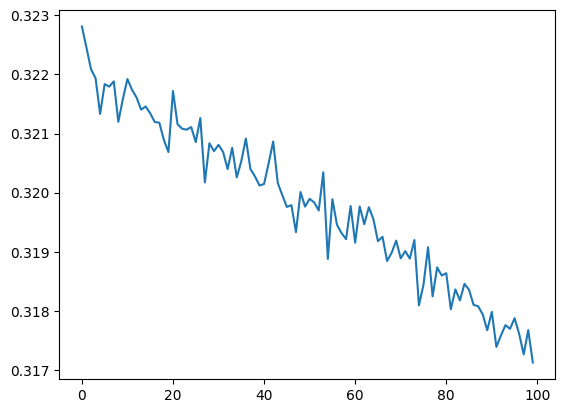

In [43]:
plt.plot(histroy.history['loss'])